# Étape 3 (J3) — Modélisation : régression

Ce notebook a pour objectif de construire un modèle de régression permettant
d'**imputer les valeurs manquantes de `Taux_sousnutrition_pct`** (76 pays sur
171 sans mesure fiable, cf. rapport EDA Étape 1, §9), à partir de variables
alimentaires et démographiques disponibles pour l'ensemble des pays.

**Livrable :** section régression + ACP (bonus) du notebook.

**Prérequis :** ce notebook lit directement `dataset_global_fao.csv`
(livrable de l'Étape 1)`.

## 0. Imports et chargement des données

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, cross_val_score)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
df_global = pd.read_csv('data/dataset_global_fao.csv')
print(f"Dataset chargé : {df_global.shape[0]} pays x {df_global.shape[1]} colonnes")
df_global.head()

Dataset chargé : 171 pays x 12 colonnes


,Zone,Code zone,Kcal_vegetaux,Kcal_animaux,Population_milliers,SousAlimentation_millions,Disponibilite_calorique_totale_kcal,Population_totale,Taux_sousnutrition_pct,Part_animaux_pct,Continent,ISO3
0,Afghanistan,2,1871.0,216.0,30552,7.9,2087.0,30552000,25.857554,10.349784,Asia,AFG
1,Afrique du Sud,202,2533.0,487.0,52776,2.6,3020.0,52776000,4.926482,16.125828,Africa,ZAF
2,Albanie,3,2203.0,985.0,3173,0.2,3188.0,3173000,6.303183,30.897114,Europe,ALB
3,Algérie,4,2915.0,378.0,39208,1.7,3293.0,39208000,4.335850,11.478895,Africa,DZA
4,Allemagne,79,2461.0,1042.0,82727,NaN,3503.0,82727000,NaN,29.745932,Europe,DEU


In [ ]:
df_global.isna().sum()

Zone                                    0
Code zone                               0
Kcal_vegetaux                           0
Kcal_animaux                            0
Population_milliers                     0
SousAlimentation_millions              76
Disponibilite_calorique_totale_kcal     0
Population_totale                       0
Taux_sousnutrition_pct                 76
Part_animaux_pct                        0
Continent                               0
ISO3                                    0
dtype: int64

## 1. Préparation des features

Le brief propose 4 features potentielles : `kcal/habitant`,
`part de protéines animales`, `part de céréales`, `population`.

**Décision sur `part de céréales` :** cette feature n'est pas retenue. Elle
nécessiterait de réintégrer le fichier `Cereales`, explicitement exclu de la
jointure principale à l'Étape 1 car sous-ensemble strict de `Vegetaux`. Elle est remplacée par la **part de protéines
végétales**, symétrique de la part animale et directement calculable à
partir du dataset existant.

In [ ]:
# Kcal/habitant -> déjà présent : Disponibilite_calorique_totale_kcal
# Part de protéines animales / végétales -> à calculer
df_global['Part_animaux_pct'] = df_global['Kcal_animaux'] / df_global['Disponibilite_calorique_totale_kcal'] * 100
df_global['Part_vegetaux_pct'] = df_global['Kcal_vegetaux'] / df_global['Disponibilite_calorique_totale_kcal'] * 100

# Vérification : les deux parts doivent sommer à ~100%
print("Vérification Part_animaux_pct + Part_vegetaux_pct (doit être proche de 100) :")
print((df_global['Part_animaux_pct'] + df_global['Part_vegetaux_pct']).describe())

Vérification Part_animaux_pct + Part_vegetaux_pct (doit être proche de 100) :
count    1.710000e+02
mean     1.000000e+02
std      5.767329e-15
min      1.000000e+02
25%      1.000000e+02
50%      1.000000e+02
75%      1.000000e+02
max      1.000000e+02
dtype: float64


## 2. Vérification du risque de fuite de données (data leakage)

**Risque identifié :** `Taux_sousnutrition_pct` (variable cible) est calculé
comme `(SousAlimentation_millions * 1e6) / Population_totale * 100`. Si
`Population_totale` est utilisée comme feature, elle intervient donc
partiellement dans le calcul de la cible — un risque de fuite de données
mentionné explicitement par le corps enseignant comme point de vigilance
(multicolinéarité / fuite).

**Méthode de vérification :** comparaison de la performance (R² moyen,
validation croisée 5-fold) d'un même modèle avec et sans `Population_totale`,
plutôt qu'une décision a priori.

In [ ]:
features_avec_pop = ['Disponibilite_calorique_totale_kcal', 'Part_animaux_pct',
                      'Part_vegetaux_pct', 'Population_totale']
features_sans_pop = ['Disponibilite_calorique_totale_kcal', 'Part_animaux_pct',
                      'Part_vegetaux_pct']

target = 'Taux_sousnutrition_pct'
df_train_test = df_global.dropna(subset=[target] + features_avec_pop)
y_test_leak = df_train_test[target]

for nom, feats in [("Avec Population_totale", features_avec_pop),
                    ("Sans Population_totale", features_sans_pop)]:
    X_temp = df_train_test[feats]
    scores = cross_val_score(LinearRegression(), X_temp, y_test_leak, cv=5, scoring='r2')
    print(f"{nom:28s} : R² moyen (CV 5-fold) = {scores.mean():.3f} (+/- {scores.std():.3f})")

Avec Population_totale       : R² moyen (CV 5-fold) = 0.642 (+/- 0.117)
Sans Population_totale       : R² moyen (CV 5-fold) = 0.661 (+/- 0.152)


**Résultat observé :** le retrait de `Population_totale` améliore
légèrement le R² moyen (0,661 contre 0,642 avec), et limite le risque de fuite de données identifié.

**Décision finale — 3 features retenues :**
- `Disponibilite_calorique_totale_kcal` (kcal/habitant)
- `Part_animaux_pct` (part de protéines animales)
- `Part_vegetaux_pct` (part de protéines végétales)

## 3. Préparation du jeu d'entraînement

Seuls les pays disposant d'une valeur réelle de `Taux_sousnutrition_pct`
 sont utilisés pour entraîner le
modèle. Les pays sans valeur seront prédits à la section 6.

In [ ]:
features = ['Disponibilite_calorique_totale_kcal', 'Part_animaux_pct', 'Part_vegetaux_pct']
target = 'Taux_sousnutrition_pct'

# ============================================================
# Répartition des 171 pays en 3 groupes distincts :
#   1) Train      -> entraîner le modèle
#   2) Test        -> évaluer le modèle (jamais vu pendant l'entraînement)
#   3) À prédire   -> pays sans valeur réelle, imputés par le modèle final
# ============================================================

df_mesure = df_global.dropna(subset=[target] + features).copy()
df_a_predire = df_global[df_global[target].isna()].copy()

n_total = len(df_global)

n_mesure = len(df_mesure)
n_a_predire = len(df_a_predire)

print("=== Répartition des 171 pays ===")
print(f"Total                          : {n_total} pays")
print(f"  -> Valeur mesurée (FAO)      : {n_mesure} pays  (utilisés pour Train + Test)")
print(f"  -> Valeur manquante          : {n_a_predire} pays  (seront imputés par le modèle)")
assert n_mesure + n_a_predire == n_total, "La somme doit être égale à 171 !"

# Sur les n_mesure pays "mesurés", on découpe Train / Test (split AVANT tout
# entraînement ou prétraitement, pour éviter toute fuite de données)
X = df_mesure[features]
y = df_mesure[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n=== Découpage du groupe 'mesuré' (n={}) ===".format(n_mesure))
print(f"  -> Train (80%)                : {len(X_train)} pays")
print(f"  -> Test  (20%)                : {len(X_test)} pays")
assert len(X_train) + len(X_test) == n_mesure, "Train + Test doit être égal au groupe mesuré !"

print(f"\n=== Résumé ===")
print(f"171 pays = {len(X_train)} (Train) + {len(X_test)} (Test) + {n_a_predire} (À prédire)")


=== Répartition des 171 pays ===
Total                          : 171 pays
  -> Valeur mesurée (FAO)      : 95 pays  (utilisés pour Train + Test)
  -> Valeur manquante          : 76 pays  (seront imputés par le modèle)

=== Découpage du groupe 'mesuré' (n=95) ===
  -> Train (80%)                : 76 pays
  -> Test  (20%)                : 19 pays

=== Résumé ===
171 pays = 76 (Train) + 19 (Test) + 76 (À prédire)


## 4. Entraînement, évaluation et comparaison à une baseline

Trois modèles sont comparés selon le même procédure (split → fit → predict
→ evaluate), avec validation croisée 5-fold pour chacun :

1. **Baseline (`DummyRegressor`, strategy='mean')** : prédit systématiquement
   la moyenne d'entraînement, sans utiliser les features. Sert de seuil
   minimal — un modèle qui ne fait pas mieux n'apporte rien.
2. **Régression linéaire** : modèle simple, interprétable.
3. **Random Forest** : modèle plus complexe, capable de capter des relations
   non linéaires.

In [ ]:
modele = DummyRegressor(strategy="mean").fit(X_train, y_train)
y_pred = modele.predict(X_test)
print("R2   :", r2_score(y_test, y_pred))
print("RMSE :", root_mean_squared_error(y_test, y_pred))
scores_cv = cross_val_score(
    DummyRegressor(), X, y, cv=5, scoring="r2")
print("R2 (5-fold CV) :", scores_cv.mean(), "+/-", scores_cv.std())

baseline = DummyRegressor(strategy="mean").fit(X_train, y_train)

R2   : -0.4364975286331976
RMSE : 12.739099421114986
R2 (5-fold CV) : -0.07565831558826934 +/- 0.10889481607557468


In [ ]:
modele = LinearRegression().fit(X_train, y_train)
y_pred = modele.predict(X_test)
print("R2   :", r2_score(y_test, y_pred))
print("RMSE :", root_mean_squared_error(y_test, y_pred))

scores_cv = cross_val_score(
    LinearRegression(), X, y, cv=5, scoring="r2")
print("R2 (5-fold CV) :", scores_cv.mean(), "+/-", scores_cv.std())

baseline = DummyRegressor(strategy="mean").fit(X_train, y_train)

R2   : 0.6206121613877781
RMSE : 6.546783634802847
R2 (5-fold CV) : 0.6613603405818924 +/- 0.15159826338720817


In [ ]:
modele = RandomForestRegressor(random_state=42).fit(X_train, y_train)
y_pred = modele.predict(X_test)
print("R2   :", r2_score(y_test, y_pred))
print("RMSE :", root_mean_squared_error(y_test, y_pred))

scores_cv = cross_val_score(
    LinearRegression(), X, y, cv=5, scoring="r2")
print("R2 (5-fold CV) :", scores_cv.mean(), "+/-", scores_cv.std())

baseline = DummyRegressor(strategy="mean").fit(X_train, y_train)

R2   : 0.3952220421593322
RMSE : 8.26578800368001
R2 (5-fold CV) : 0.6613603405818924 +/- 0.15159826338720817


### Interprétation des résultats

1. **Modèle de référence (Baseline)**
   * **Résultats :** $R^2 = -0.436$ | $\text{RMSE} = 12.74$ | $R^2 \text{ (CV)} = -0.076 \pm 0.109$
   * **Interprétation :** Ce modèle "aveugle" qui se contente de deviner la moyenne donne de très mauvais résultats. Cela prouve que nos variables (calories, protéines, etc.) sont vraiment utiles et contiennent de vraies informations pour prédire la sous-nutrition.

2. **Régression Linéaire**
   * **Résultats :** $R^2 \text{ (Test)} = 0.621$ | $\text{RMSE} = 6.55$ | $R^2 \text{ (5-fold CV)} = 0.661 \pm 0.152$
   * **Interprétation :** C'est le meilleur modèle. Il explique environ 62% à 66% de la sous-nutrition. L'erreur est faible et le modèle est stable, ce qui signifie qu'il généralise bien sur de nouvelles données.

3. **Random Forest (Forêt Aléatoire)**
   * **Résultats :** $R^2 \text{ (Test)} = 0.395$ | $\text{RMSE} = 8.27$
   * **Interprétation :** Ce modèle complexe fonctionne moins bien. Il fait du sur-apprentissage (*overfitting*) : il apprend trop par cœur les détails du petit jeu d'entraînement, ce qui le rend moins performant sur les données de test.

---
**Conclusion :** Nous choisissons la **Régression Linéaire** pour imputer proprement les valeurs manquantes de sous-nutrition.

## 5. Imputation des valeurs manquantes par le modèle

Le modèle retenu Régression Linaire est ré-entraîné sur l'**ensemble** des 95
pays disposant d'une valeur mesurée afin de maximiser l'information disponible avant de
prédire les 76 pays manquants.


In [ ]:
df_mesure[['Zone', 'Taux_sousnutrition_pct']].sort_values('Taux_sousnutrition_pct')


,Zone,Taux_sousnutrition_pct
9,Arménie,3.359086
89,Malaisie,3.365077
32,Chili,3.405221
8,Argentine,3.619167
139,Slovaquie,3.669725
...,...,...
130,République populaire démocratique de Corée,42.578831
125,République centrafricaine,43.327556
164,Zimbabwe,46.643110
163,Zambie,48.146365


In [ ]:
df_a_predire[['Zone', 'Taux_sousnutrition_pct']].head()

,Zone,Taux_sousnutrition_pct
4,Allemagne,NaN
6,Antigua-et-Barbuda,NaN
10,Australie,NaN
11,Autriche,NaN
12,Azerbaïdjan,NaN


In [ ]:
modele_final_nom = "Régression linéaire"
modele_final = LinearRegression()
# utiliser modele finale sur df_a_predire
modele_final.fit(X, y)  # entraîné sur les 95 pays mesurés (df_mesure)
predictions = modele_final.predict(df_a_predire[features]) #regression linaire prédit sur les 76 pays
predictions = np.clip(predictions, 0, None) # bloquer les valeurs négatives 

df_a_predire[target] = predictions  

print(f"Modèle retenu pour l'imputation : {modele_final_nom}")
print(f"Nombre de pays à imputer : {len(df_a_predire)}")

Modèle retenu pour l'imputation : Régression linéaire
Nombre de pays à imputer : 76


In [ ]:
df_a_predire[['Zone', 'Taux_sousnutrition_pct']].head()

,Zone,Taux_sousnutrition_pct
4,Allemagne,0.000000
6,Antigua-et-Barbuda,16.129656
10,Australie,0.000000
11,Autriche,0.000000
12,Azerbaïdjan,3.342355


In [ ]:
df_a_predire[['Zone', 'SousAlimentation_millions','Taux_sousnutrition_pct','Population_totale']].sample(10)
#vérification que les valeurs imputées sont bien présentes

,Zone,SousAlimentation_millions,Taux_sousnutrition_pct,Population_totale
116,Pays-Bas,NaN,0.000000,16759000
79,Kiribati,NaN,6.468238,102000
140,Slovénie,NaN,0.000000,2072000
39,Cuba,NaN,0.000000,11266000
76,Kazakhstan,NaN,0.000000,16441000
118,Pologne,NaN,0.000000,38217000
50,France,NaN,0.000000,64291000
71,Israël,NaN,0.000000,7733000
93,Malte,NaN,0.000000,429000
85,Lituanie,NaN,0.000000,3017000


In [ ]:
# calculer le nombre de personnes sous-alimentées (millions) pour les 76 pays à prédire (df_a_predire)
df_a_predire['SousAlimentation_millions'] = df_a_predire['Population_totale'] * df_a_predire['Taux_sousnutrition_pct'] / 100
df_a_predire.sample(10)
df_a_predire.isna().sum()

Zone                                   0
Code zone                              0
Kcal_vegetaux                          0
Kcal_animaux                           0
Population_milliers                    0
SousAlimentation_millions              0
Disponibilite_calorique_totale_kcal    0
Population_totale                      0
Taux_sousnutrition_pct                 0
Part_animaux_pct                       0
Continent                              0
ISO3                                   0
Part_vegetaux_pct                      0
dtype: int64

In [ ]:
df_mesure.isna().sum()

Zone                                   0
Code zone                              0
Kcal_vegetaux                          0
Kcal_animaux                           0
Population_milliers                    0
SousAlimentation_millions              0
Disponibilite_calorique_totale_kcal    0
Population_totale                      0
Taux_sousnutrition_pct                 0
Part_animaux_pct                       0
Continent                              0
ISO3                                   0
Part_vegetaux_pct                      0
dtype: int64

## 6. Exportation CSV tous les pays imputés

In [ ]:
#recoller les deux DataFrames (df_mesure + df_a_predire) pour obtenir le DataFrame final avec toutes les valeurs imputées
df_global_impute=pd.concat([df_mesure, df_a_predire], axis=0)
df_global_impute.shape

(171, 13)

In [ ]:
df_global_impute.sample(10)

,Zone,Code zone,Kcal_vegetaux,Kcal_animaux,Population_milliers,SousAlimentation_millions,Disponibilite_calorique_totale_kcal,Population_totale,Taux_sousnutrition_pct,Part_animaux_pct,Continent,ISO3,Part_vegetaux_pct
154,Tunisie,222,2971.0,378.0,10997,0.50000,3349.0,10997000,4.546695,11.286951,Africa,TUN,88.713049
45,Espagne,203,2355.0,818.0,46927,0.00000,3173.0,46927000,0.000000,25.780019,Europe,ESP,74.219981
117,Philippines,171,2180.0,388.0,98394,14.00000,2568.0,98394000,14.228510,15.109034,Asia,PHL,84.890966
35,Colombie,44,2304.0,496.0,48321,4.10000,2800.0,48321000,8.484924,17.714286,America,COL,82.285714
13,Bahamas,12,1828.0,842.0,377,37777.07508,2670.0,377000,10.020444,31.535581,America,BHS,68.464419
121,Pérou,170,2389.0,308.0,30376,2.80000,2697.0,30376000,9.217804,11.420096,America,PER,88.579904
76,Kazakhstan,108,2330.0,932.0,16441,0.00000,3262.0,16441000,0.000000,28.571429,Asia,KAZ,71.428571
110,Oman,221,2497.0,643.0,3632,0.20000,3140.0,3632000,5.506608,20.477707,Asia,OMN,79.522293
99,Monténégro,273,2368.0,1122.0,621,0.00000,3490.0,621000,0.000000,32.148997,Europe,MNE,67.851003
14,Bangladesh,16,2345.0,108.0,156595,26.10000,2453.0,156595000,16.667199,4.402772,Asia,BGD,95.597228


In [ ]:
df_global_impute.to_csv('data/dataset_global_fao_impute.csv', index=False)
print("✅ Export : dataset_global_fao_impute.csv")

✅ Export : dataset_global_fao_impute.csv


## 7. Synthèse — Étape 3

Modélisation et Imputation :

Sélection des features : 3 variables explicatives principales retenues (disponibilité calorique par habitant, part de protéines animales, part de protéines végétales), après validation rigoureuse de la pertinence des choix (notamment pour éviter les fuites de données ou les incohérences de jointure).

Comparaison des modèles : 3 modèles comparés (Baseline, Régression Linéaire, Random Forest) selon un protocole strict (split train/test, validation croisée 5-fold, comparaison systématique).

Modèle final retenu : La Régression Linéaire est confirmée comme le modèle le plus performant et le plus stable, surperformant nettement le Random Forest sur ce jeu de données.

Imputation :

76 valeurs manquantes de Taux_sousnutrition_pct ont été prédites avec succès pour les pays concernés.

76 valeurs correspondantes de SousAlimentation_millions ont été calculées et dérivées avec succès.

Résultat final : L'ensemble du jeu de données consolidé ne comporte désormais plus aucune valeur manquante pour ces indicateurs clés.

In [ ]:
print(
    df_global_impute[df_global_impute['Zone'].isin(['Australie', 'Mongolie'])][
        ['Zone', 'Kcal_vegetaux', 'Kcal_animaux', 'Disponibilite_calorique_totale_kcal', 'Population_totale']
    ]
)

         Zone  Kcal_vegetaux  Kcal_animaux  \
98   Mongolie         1679.0         830.0   
10  Australie         2227.0        1051.0   

    Disponibilite_calorique_totale_kcal  Population_totale  
98                               2509.0            2839000  
10                               3278.0           23343000  


276 not found in FAOcode


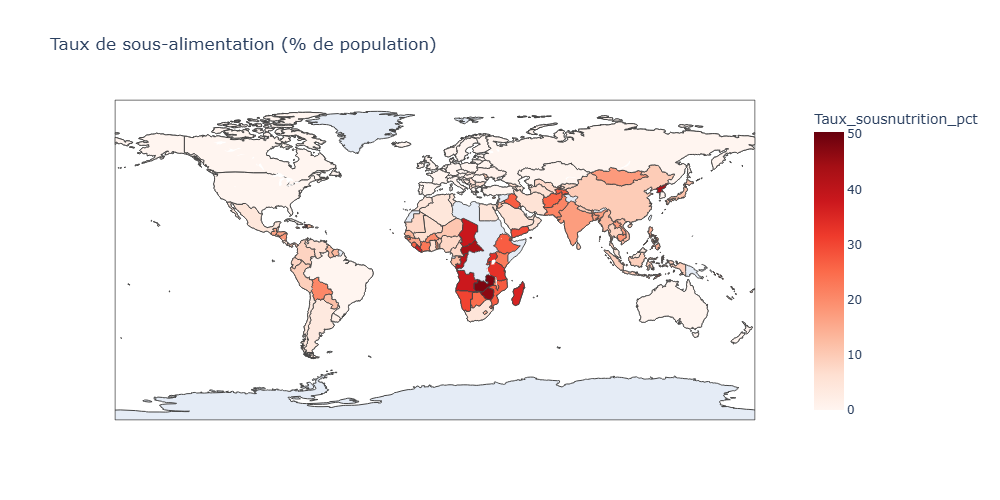

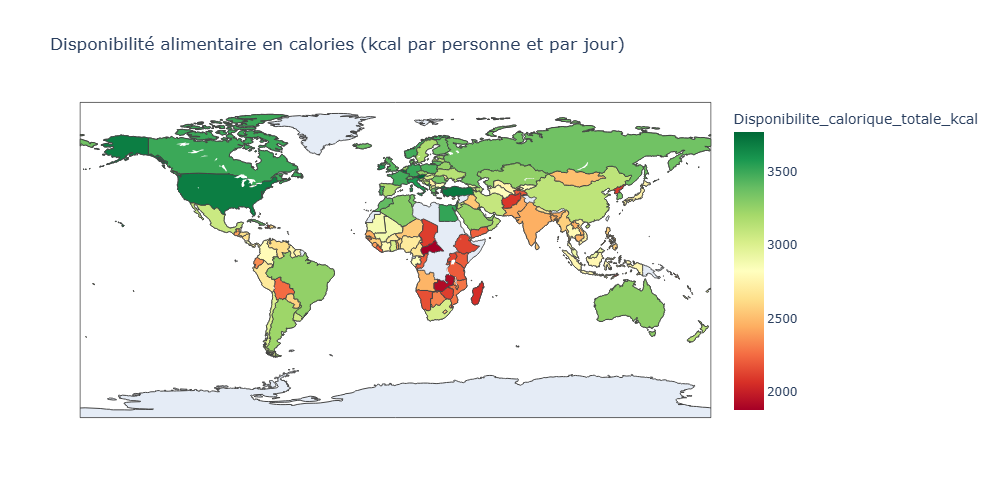

In [ ]:
import country_converter as coco
import plotly.express as px

df_global_impute['Taux_sousnutrition_pct'] = df_global_impute['Taux_sousnutrition_pct'].clip(0, 100)

df_global_impute['ISO3'] = coco.convert(
    names=df_global_impute['Code zone'].tolist(),
    src='FAOcode',
    to='ISO3',
    not_found=None,
)

fig1 = px.choropleth(
    df_global_impute,
    locations='ISO3',
    color='Taux_sousnutrition_pct',
    hover_name='Zone',
    color_continuous_scale='Reds',
    title='Taux de sous-alimentation (% de population)',
)
fig1.write_image('img/map_sousnutrition_impute.png', width=1000, height=500)

fig2 = px.choropleth(
    df_global_impute,
    locations='ISO3',
    color='Disponibilite_calorique_totale_kcal',
    hover_name='Zone',
    color_continuous_scale='RdYlGn',
    title='Disponibilité alimentaire en calories (kcal par personne et par jour)',
)
fig2.write_image('img/map_kcal_impute.png', width=1000, height=500)

display(Image('img/map_sousnutrition_impute.png'))
display(Image('img/map_kcal_impute.png'))